In [19]:
import geopandas as gp
from rasterio.features import shapes
from shapely.geometry import shape
import rioxarray
import matplotlib.pyplot as plt
import contextily as cx

In [5]:
ndvi = rioxarray.open_rasterio("data/ndvi_day2.tif", masked=True)
ndvi = ndvi.squeeze("band", drop=True)
ndvi

<xarray.DataArray (y: 11004, x: 11010)> Size: 485MB
[121154040 values with dtype=float32]
Coordinates:
  * y            (y) float64 88kB 9.1e+06 9.1e+06 9.1e+06 ... 8.99e+06 8.99e+06
  * x            (x) float64 88kB 3.997e+05 3.997e+05 ... 5.098e+05 5.098e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [6]:
mask=(ndvi < 0.3).values.astype("uint8")

In [12]:
no_transform = list(shapes(mask, mask=mask == 1))
print(no_transform[0][0]["coordinates"][0][:3])

[(11009.0, 10042.0), (11009.0, 10043.0), (11010.0, 10043.0)]


In [13]:
yes_transform = list(shapes(mask, mask=mask == 1, transform=ndvi.rio.transform()))
print(yes_transform[0][0]["coordinates"][0][:3])

[(509780.0, 8999690.0), (509780.0, 8999680.0), (509790.0, 8999680.0)]


In [15]:
gdf = gp.GeoDataFrame(
    geometry=[shape(geom) for geom, val in yes_transform],
    crs=ndvi.rio.crs,     
)
print(len(gdf), "poligoni")
gdf.head()

199 poligoni


,geometry
0,"POLYGON ((509780 8999690, 509780 8999680, 5097..."
1,"POLYGON ((509750 8999640, 509750 8999630, 5097..."
2,"POLYGON ((509740 8999620, 509740 8999610, 5097..."
3,"POLYGON ((509730 8999610, 509730 8999600, 5097..."
4,"POLYGON ((509650 8999330, 509650 8999320, 5096..."


In [16]:
gdf["area_m2"] = gdf.geometry.area                     
gdf["area_gradi2"] = gdf.to_crs("EPSG:4326").geometry.area  

gdf[["area_m2", "area_gradi2"]].describe()

C:\Users\angel\AppData\Local\Temp\ipykernel_44464\1561334129.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["area_gradi2"] = gdf.to_crs("EPSG:4326").geometry.area


,area_m2,area_gradi2
count,199.000000,1.990000e+02
mean,845.226131,6.957910e-08
std,3109.185613,2.559524e-07
min,100.000000,8.230322e-09
25%,100.000000,8.231537e-09
50%,100.000000,8.231934e-09
75%,200.000000,1.646420e-08
max,27100.000000,2.230907e-06


In [20]:
big = gdf[gdf["area_m2"] >= 5000].copy()
print(len(gdf), "->", len(big), "polygons over 0.5 ha")
big["area_ha"] = big["area_m2"] / 10_000

199 -> 9 polygons over 0.5 ha


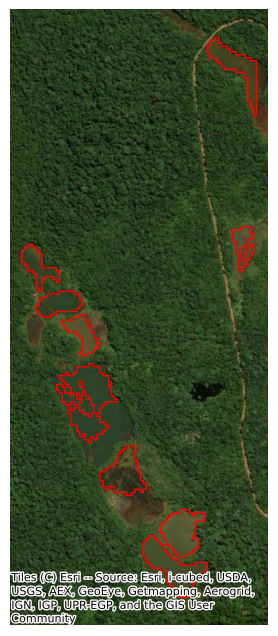

In [21]:
big.to_file("data/non_veget_day3.geojson", driver="GeoJSON")

ax = big.to_crs(epsg=3857).plot(
    figsize=(8, 8), facecolor="none", edgecolor="red", linewidth=1
)
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery)
ax.set_axis_off()
plt.show()